## Limpieza de datos: ingreso_promedio_población_ocupada_sexo.csv obtenido de Cuadro_de_indicadores_ITLP_4T2024.xlsx

In [21]:
# Importamos las bibliotecas necesarias
import pandas as pd
import numpy as np

# Declaramos la ruta de la obtendremos el archivo
ruta = '../data/ingreso_promedio_población_ocupada_sexo.csv'
df_raw = pd.read_csv(ruta, header=None)

In [22]:
#Extraemos años y trimestres, saltamos las filas inutilizadas

anios_row = df_raw.iloc[2, 4:].values
trimestres_row = df_raw.iloc[3, 4:].values

In [23]:
#Limpiamos usando ffill
anios = []
last_year = None
for a in anios_row:
    if pd.notna(a) and str(a).strip() != '':
        last_year = str(a).replace('.0', '').strip()
    anios.append(last_year)

In [24]:
# Extraemos solo los datos a nivel nacional
df_nacional = df_raw.iloc[4:6, 3:].copy()
#Asignamos nombres a las columnas
df_nacional.columns = ["Sexo"] + [f"{y}_{t}" for y, t in zip(anios, trimestres_row)]


In [25]:
#Transformamos (melt) de formato ancho a formato largo
df_melt = df_nacional.melt(id_vars=["Sexo"], var_name="Periodo", value_name="Ingreso")

In [26]:
#Separar la columna Periodo en Año y Trimestre para usar como llave de cruce
df_melt[['anio', 'trimestre']] = df_melt['Periodo'].str.split('_', expand=True)

#Limpiezas de caracteres estorbos ($ y ",")
df_melt['Ingreso'] = df_melt['Ingreso'].astype(str).str.replace('$', '', regex=False)\
                                           .str.replace(',', '', regex=False)\
                                           .str.strip()

In [27]:
#Manejo de valores faltantes por COVID 19 y Huracán Otis
df_melt['Ingreso'] = df_melt['Ingreso'].replace({'ND': np.nan, 'nan': np.nan})
df_melt['Ingreso'] = pd.to_numeric(df_melt['Ingreso'], errors='coerce')
df_melt['trimestre'] = df_melt['trimestre'].replace({'ll*': 'II', 'IV**': 'IV'})

In [28]:
#Pivotar para tener variables numéricas por sexo
df_final = df_melt.pivot_table(index=['anio', 'trimestre'], columns='Sexo', values='Ingreso').reset_index()
df_final.columns.name = None
df_final = df_final.rename(columns={'Hombres': 'ingreso_hombres', 'Mujeres': 'ingreso_mujeres'})

In [29]:
#Calculo para una variable extra (Brecha salarial)
df_final['brecha_salarial'] = (df_final['ingreso_hombres'] - df_final['ingreso_mujeres']) / df_final['ingreso_hombres']

In [30]:
#Orden cronológico para su uso posterior
trimestre_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4}
df_final['trim_num'] = df_final['trimestre'].map(trimestre_map)
df_final = df_final.sort_values(by=['anio', 'trim_num']).drop(columns=['trim_num']).reset_index(drop=True)

In [31]:
# Mostramos las primeras filas del df actualizado
df_final.head(10)

,anio,trimestre,ingreso_hombres,ingreso_mujeres,brecha_salarial
0,2005,I,7421.18,5353.32,0.278643
1,2005,II,7410.56,5356.61,0.277165
2,2005,III,7318.11,5423.90,0.258839
3,2005,IV,7540.13,5587.89,0.258913
4,2006,I,7572.22,5631.87,0.256246
5,2006,II,7654.53,5672.52,0.258933
6,2006,III,7734.31,5698.60,0.263205
7,2006,IV,7593.16,5565.39,0.267052
8,2007,I,7673.48,5661.02,0.262262
9,2007,II,7812.78,5697.51,0.270745


In [32]:
#Ultima verificacion
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   anio             79 non-null     object 
 1   trimestre        79 non-null     object 
 2   ingreso_hombres  79 non-null     float64
 3   ingreso_mujeres  79 non-null     float64
 4   brecha_salarial  79 non-null     float64
dtypes: float64(3), object(2)
memory usage: 3.2+ KB
None


In [33]:
#Finalmente guardamos el df obtenido en un nuevo archivo .csv
df_final.to_csv('../data/clean_data/ingreso_promedio_poblacion_ocupada_sexo_clean.csv', index=False)

## Visualizacion a partir de la construccion de una Serie de tiempo

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# Diccionario para convertir romanos a el primer mes del trimestre
mapping = {'I': '01-01', 'II': '04-01', 'III': '07-01', 'IV': '10-01'}

# Creamos la columna 'fecha' combinando año, el guion y el mes correspondiente
df_final['fecha'] = pd.to_datetime(df_final['anio'].astype(str) + '-' + df_final['trimestre'].map(mapping))

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

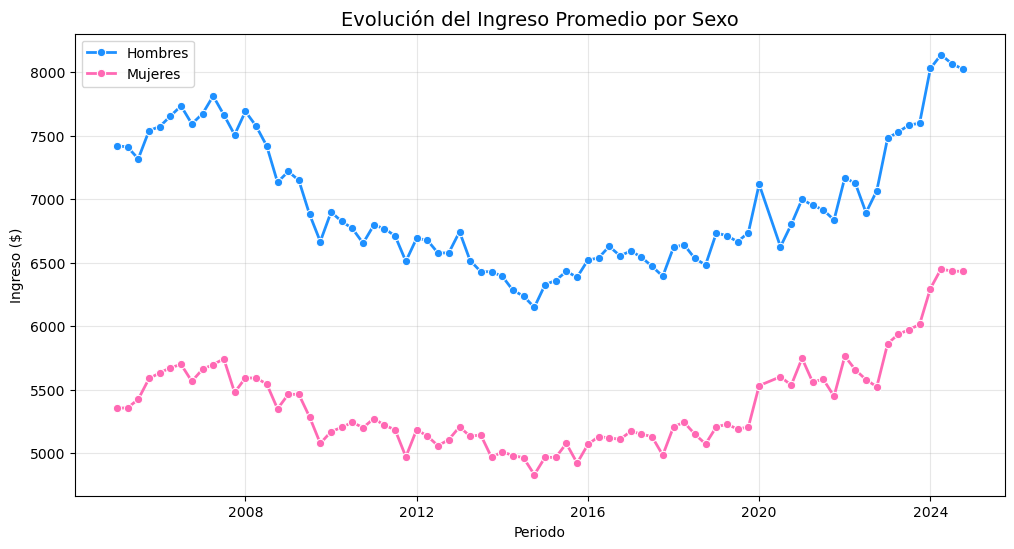

In [36]:
# Visualizacion:
plt.figure(figsize=(12, 6))

# Graficamos ambas líneas
sns.lineplot(data=df_final, x='fecha', y='ingreso_hombres', label='Hombres', color= 'dodgerblue', marker='o', linewidth=2)
sns.lineplot(data=df_final, x='fecha', y='ingreso_mujeres', label='Mujeres', color= 'hotpink', marker='o', linewidth=2)

plt.title('Evolución del Ingreso Promedio por Sexo', fontsize=14)
plt.ylabel('Ingreso ($)')
plt.xlabel('Periodo')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()